<a href="https://colab.research.google.com/github/lorida0777/Classification_genre/blob/main/genre_classification__cv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification du genre (Homme / Femme) à partir d’images faciales
## Projet de Computer Vision & Deep Learning

**Outils :** Google Colab, TensorFlow / Keras  
**Type :** Classification binaire  
**Dataset :** CelebA (images réalignées)

**Auteurs :**  
- ANDRIATSIFERANA No Kanto Lorida  
- RALALASON Rodéo


## Introduction

La classification automatique du genre à partir d’images faciales est une tâche classique
en Computer Vision, avec de nombreuses applications en biométrie, analyse démographique
et systèmes intelligents.

Ce projet vise à comparer plusieurs architectures de Deep Learning pour la classification
binaire Homme / Femme à partir d’images de visages, en utilisant des réseaux de neurones
convolutifs (CNN) entraînés **from scratch** et par **Transfer Learning**.


## Contexte

L’essor du deep learning, combiné à l’augmentation de la puissance de calcul
(GPU), a profondément transformé les méthodes de vision par ordinateur.

Les réseaux de neurones convolutifs (CNN) permettent d’extraire automatiquement
des caractéristiques discriminantes à partir des images, sans recours à une
ingénierie manuelle des features.


## État de l’art

Les approches modernes de classification d’images reposent sur :

- Les CNN entraînés from scratch (LeNet, AlexNet-like)
- Le Transfer Learning à partir de modèles pré-entraînés sur ImageNet
- Des architectures optimisées en profondeur ou en efficacité

Dans ce projet, six architectures ont été étudiées :

- CNN Baseline
- Deep CNN avec Batch Normalization
- VGG16
- ResNet50
- MobileNetV2
- EfficientNetB0


## Problématique

Comment le choix de l’architecture influence-t-il la performance d’un modèle
de classification binaire du genre à partir d’images faciales ?

Les questions étudiées sont :

- Les modèles entraînés from scratch sont-ils suffisants ?
- Le Transfer Learning améliore-t-il significativement les performances ?
- Quel est le meilleur compromis entre précision, temps d’entraînement et
  nombre de paramètres ?


## Méthodologie

La démarche expérimentale suivie est la suivante :

1. Chargement et organisation du dataset CelebA
2. Prétraitement et augmentation des données
3. Implémentation de six modèles CNN distincts
4. Entraînement avec les mêmes conditions expérimentales
5. Évaluation et comparaison des performances


## Dataset

### Provenance

Le dataset utilisé est issu de **CelebA (Celebrity Faces Attributes Dataset)**.

Lien officiel :
https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html

### Structure utilisée dans ce projet
```
genre/
├── female/   (images de femmes)
│   ├── image_001.jpg
│   ├── image_002.jpg
│   └── ...
└── male/    (images d'hommes)
    ├── image_001.jpg
    ├── image_002.jpg
    └── ...
```

Nombre total d’images : **1813**  
Split : **80% entraînement / 20% validation**  
Résolution cible : **128 × 128**


## Architecture technique

### Pipeline global

1. Chargement des images depuis Google Drive
2. Prétraitement :
   - Redimensionnement
   - Normalisation
   - Data augmentation
3. Modèles CNN (6 architectures)
4. Entraînement avec Adam et Binary Crossentropy
5. Évaluation des performances


## Hyperparamètres

- Taille des images : 128 × 128
- Batch size : 256
- Optimiseur : Adam (lr = 0.001)
- Fonction de perte : Binary Crossentropy
- Epochs max : 30
- EarlyStopping : patience = 10
- ReduceLROnPlateau : factor = 0.5, patience = 5
- Métrique principale : Accuracy


####  Prétraitement

**Augmentation de données** (Data Augmentation) :

- **Normalisation** : Division par 255 pour ramener les pixels dans [0, 1]
- **Rotation** : ±20°
- **Translation** : ±20% (horizontal et vertical)
- **Cisaillement** (Shear) : 20%
- **Zoom** : ±20%
- **Flip horizontal** : Aléatoire
- **Mode de remplissage** : 'nearest'

**Justification** : L'augmentation de données permet de :

- Augmenter artificiellement la taille du dataset
- Améliorer la généralisation du modèle
- Réduire le surapprentissage (overfitting)
- Rendre le modèle robuste aux variations d'orientation, position et échelle

###  Architecture Technique

####  Schéma Synoptique Global

```
┌─────────────────────────────────────────────────────────────────┐
│                    PIPELINE DE CLASSIFICATION                   │
└─────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────┐
│  ÉTAPE 1 : CHARGEMENT ET PRÉTRAITEMENT DES DONNÉES              │
├─────────────────────────────────────────────────────────────────┤
│  • Chargement depuis Google Drive                               │
│  • ImageDataGenerator avec augmentation                         │
│  • Normalisation [0, 1]                                         │
│  • Batch Size: 256                                              │
│  • Epoch: 30                                                    │
│  • Split: 80% train / 20% validation                            │
└─────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────┐
│  ÉTAPE 2 : CONSTRUCTION DES MODÈLES                             │
├─────────────────────────────────────────────────────────────────┤
│                                                                 │
│  ┌──────────────┐  ┌──────────────┐  ┌──────────────┐           │
│  │ CNN Baseline │  │  Deep CNN    │  │    VGG16     │           │
│  │   (Simple)   │  │ (BatchNorm)  │  │  (Transfer)  │           │
│  └──────────────┘  └──────────────┘  └──────────────┘           │
│                                                                 │
│  ┌──────────────┐  ┌──────────────┐  ┌──────────────┐           │
│  │   ResNet50   │  │ MobileNetV2  │  │EfficientNetB0│           │
│  │  (Transfer)  │  │   (Léger)    │  │   (Moderne)  │           │
│  └──────────────┘  └──────────────┘  └──────────────┘           │
└─────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────┐
│  ÉTAPE 3 : ENTRAÎNEMENT                                         │
├─────────────────────────────────────────────────────────────────┤
│  • Optimiseur: Adam (lr=0.001)                                  │
│  • Loss: Binary Crossentropy                                    │
│  • Métriques: Accuracy, Precision, Recall                       │
│  • Callbacks: EarlyStopping, ReduceLROnPlateau                  │
│  • Epochs max: 50                                               │
└─────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────┐
│  ÉTAPE 4 : ÉVALUATION                                           │
├─────────────────────────────────────────────────────────────────┤
│  • Accuracy, Precision, Recall, F1-Score                        │
│  • Matrice de confusion                                         │
│  • Courbe ROC et AUC                                            │
│  • Analyse des erreurs                                          │
└─────────────────────────────────────────────────────────────────┘
                                │
                                ▼
┌─────────────────────────────────────────────────────────────────┐
│  ÉTAPE 5 : SAUVEGARDE                                           │
├─────────────────────────────────────────────────────────────────┤
│  • Modèle complet (.keras)                                      │
│  • Poids (.h5)                                                  │
│  • Historique d'entraînement (.npy)                             │
│  • Métadonnées (.json)                                          │
└─────────────────────────────────────────────────────────────────┘
```


####  Architectures Implémentées

##### Modèle 1 : CNN Baseline

**Architecture** :

```
Input (128×128×3)
    ↓
[Conv2D(32, 3×3) + ReLU + MaxPool(2×2)]
    ↓
[Conv2D(64, 3×3) + ReLU + MaxPool(2×2)]
    ↓
[Conv2D(128, 3×3) + ReLU + MaxPool(2×2)]
    ↓
Flatten
    ↓
Dense(128, ReLU) + Dropout(0.5)
    ↓
Dense(1, Sigmoid)
```

**Paramètres** : ~3.3M
**Justification** : Modèle simple servant de baseline pour comparaison

---

##### Modèle 2 : Deep CNN avec Batch Normalization

**Architecture** :

```
Input (128×128×3)
    ↓
[Conv2D(32) + BatchNorm + ReLU + Conv2D(32) + BatchNorm + ReLU + MaxPool + Dropout(0.25)] × 1
    ↓
[Conv2D(64) + BatchNorm + ReLU + Conv2D(64) + BatchNorm + ReLU + MaxPool + Dropout(0.25)] × 1
    ↓
[Conv2D(128) + BatchNorm + ReLU + Conv2D(128) + BatchNorm + ReLU + MaxPool + Dropout(0.25)] × 1
    ↓
[Conv2D(256) + BatchNorm + ReLU + MaxPool + Dropout(0.25)] × 1
    ↓
Flatten
    ↓
Dense(512) + BatchNorm + Dropout(0.5)
    ↓
Dense(256) + BatchNorm + Dropout(0.5)
    ↓
Dense(1, Sigmoid)
```

**Paramètres** : ~9M
**Innovations** :

- Batch Normalization : Stabilise l'entraînement et accélère la convergence
- Dropout progressif : Régularisation pour éviter l'overfitting
- Architecture plus profonde : Capacité d'apprentissage accrue

---

##### Modèle 3 : VGG16 (Transfer Learning)

**Architecture** :

```
VGG16 Base (Pré-entraînée ImageNet, couches gelées)
    ↓
Flatten
    ↓
Dense(256, ReLU) + Dropout(0.5)
    ↓
Dense(128, ReLU) + Dropout(0.3)
    ↓
Dense(1, Sigmoid)
```

**Paramètres totaux** : ~14.7M (pré-entraînés) + ~200K (entraînables)
**Avantages** :

- Features génériques pré-apprises
- Convergence rapide
- Performance élevée même avec peu de données

---

##### Modèle 4 : ResNet50 (Transfer Learning)

**Architecture** :

```
ResNet50 Base (Pré-entraînée ImageNet, couches gelées)
    ↓
GlobalAveragePooling2D
    ↓
Dense(256, ReLU) + Dropout(0.5)
    ↓
Dense(128, ReLU) + Dropout(0.3)
    ↓
Dense(1, Sigmoid)
```

**Paramètres totaux** : ~23.5M (pré-entraînés) + ~170K (entraînables)
**Spécificités** :

- Skip connections : Permet l'entraînement de réseaux très profonds
- GlobalAveragePooling : Réduit la dimensionnalité sans perte d'information

---

##### Modèle 5 : MobileNetV2 (Léger)

**Architecture** :

```
MobileNetV2 Base (Pré-entraînée ImageNet, couches gelées)
    ↓
GlobalAveragePooling2D
    ↓
Dense(128, ReLU) + Dropout(0.4)
    ↓
Dense(64, ReLU) + Dropout(0.3)
    ↓
Dense(1, Sigmoid)
```

# CODE
## 1. INSTALLATION ET IMPORTS

In [1]:
# Installation des bibliothèques nécessaires
!pip install -q tensorflow scikit-learn matplotlib seaborn

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import time
import os
from google.colab import drive

# Configuration pour reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# Vérification du GPU
print("GPU disponible:", tf.config.list_physical_devices('GPU'))
print("Version TensorFlow:", tf.__version__)

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Version TensorFlow: 2.19.0


## 2. MONTAGE DE GOOGLE DRIVE ET CHARGEMENT DES DONNÉES

In [2]:
# Montage de Google Drive
drive.mount('/content/drive')

# MODIFIER CE CHEMIN selon votre structure Google Drive
BASE_PATH = '/content/drive/MyDrive/genre'

# Vérification de l'existence des dossiers
print("\nVérification de la structure des données:")
print(f"Chemin de base: {BASE_PATH}")
print(f"Dossier 'female' existe: {os.path.exists(os.path.join(BASE_PATH, 'female'))}")
print(f"Dossier 'male' existe: {os.path.exists(os.path.join(BASE_PATH, 'male'))}")

if os.path.exists(BASE_PATH):
    for folder in ['female', 'male']:
        folder_path = os.path.join(BASE_PATH, folder)
        if os.path.exists(folder_path):
            num_images = len([f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  - {folder}: {num_images} images")

Mounted at /content/drive

Vérification de la structure des données:
Chemin de base: /content/drive/MyDrive/genre
Dossier 'female' existe: True
Dossier 'male' existe: True
  - female: 906 images
  - male: 907 images


## 3. CONFIGURATION DES HYPERPARAMÈTRES

## Hyperparamètres

- Taille des images : 128 × 128
- Batch size : 256
- Optimiseur : Adam (lr = 0.001)
- Fonction de perte : Binary Crossentropy
- Epochs max : 20
- EarlyStopping : patience = 10
- ReduceLROnPlateau : factor = 0.5, patience = 5
- Métrique principale : Accuracy


In [3]:
# Paramètres globaux
IMG_SIZE = 128
BATCH_SIZE = 256
EPOCHS = 30
VALIDATION_SPLIT = 0.2
LEARNING_RATE = 0.001

# Classes
CLASS_NAMES = ['male', 'female']
NUM_CLASSES = 1  # Classification binaire avec sigmoid

print(f"\nConfiguration:")
print(f"  - Taille des images: {IMG_SIZE}x{IMG_SIZE}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Époques: {EPOCHS}")
print(f"  - Split validation: {VALIDATION_SPLIT}")


Configuration:
  - Taille des images: 128x128
  - Batch size: 256
  - Époques: 30
  - Split validation: 0.2


## 4. PRÉTRAITEMENT ET DATA AUGMENTATION

### 4.1 Générateurs d'Images

Nous utilisons l'augmentation de données pour améliorer la généralisation:
- Rotation aléatoire (±20°)
- Zoom aléatoire (±20%)
- Flip horizontal
- Normalisation des pixels [0, 1]

In [4]:
# Générateur pour l'entraînement avec augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

# Générateur pour la validation (seulement normalisation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# Chargement des données d'entraînement
train_generator = train_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    shuffle=True,
    seed=42
)

# Chargement des données de validation
validation_generator = val_datagen.flow_from_directory(
    BASE_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    shuffle=False,
    seed=42
)

print("\nClasses détectées:", train_generator.class_indices)
print(f"Nombre d'images d'entraînement: {train_generator.samples}")
print(f"Nombre d'images de validation: {validation_generator.samples}")


Found 1451 images belonging to 2 classes.
Found 362 images belonging to 2 classes.

Classes détectées: {'female': 0, 'male': 1}
Nombre d'images d'entraînement: 1451
Nombre d'images de validation: 362


### 4.2 Visualisation d'exemples augmentés


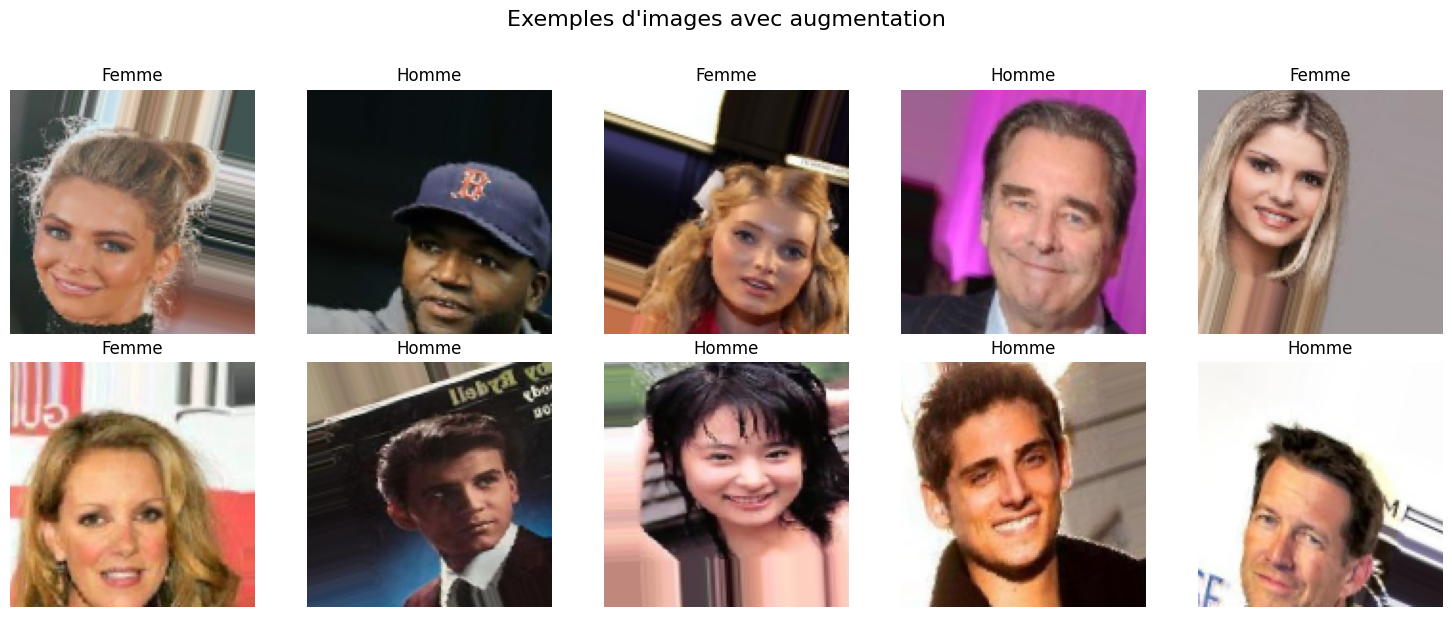

In [5]:
def plot_augmented_samples():
    """Visualise des exemples d'images avec augmentation"""
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))

    sample_batch, sample_labels = next(train_generator)

    for i, ax in enumerate(axes.flat):
        if i < len(sample_batch):
            ax.imshow(sample_batch[i])
            label = "Femme" if sample_labels[i] == 0 else "Homme"
            ax.set_title(f'{label}')
            ax.axis('off')

    plt.suptitle('Exemples d\'images avec augmentation', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

plot_augmented_samples()

## 5. DÉFINITION DES CALLBACKS

Ces callbacks permettent:
- **EarlyStopping**: Arrêt anticipé si pas d'amélioration
- **ReduceLROnPlateau**: Réduction du learning rate en cas de stagnation

In [6]:
def get_callbacks():
    """Retourne les callbacks standards pour l'entraînement"""
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )

    return [early_stopping, reduce_lr]

## 6. IMPLÉMENTATION DES MODÈLES

### 6.1 Modèle 1: CNN Basique (Baseline)

Architecture simple avec 3 blocs convolutionnels pour établir une baseline.

In [7]:
def build_cnn_baseline():
    """
    CNN simple avec 3 blocs Conv-MaxPool
    Architecture de référence pour comparaison
    """
    model = models.Sequential([
        # Bloc 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.MaxPooling2D((2, 2)),

        # Bloc 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Bloc 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Classification
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name='CNN_Baseline')

    return model

### 6.2 Modèle 2: CNN Profond avec Batch Normalization

Architecture plus profonde avec normalisation par batch et dropout pour régularisation.

In [8]:
def build_deep_cnn():
    """
    CNN profond avec Batch Normalization et Dropout
    Meilleure capacité d'apprentissage que le baseline
    """
    model = models.Sequential([
        # Bloc 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloc 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloc 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Bloc 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classification
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ], name='Deep_CNN')

    return model

### 6.3 Modèle 3: VGG16 (Transfer Learning)

Utilisation de VGG16 pré-entraîné sur ImageNet.
Architecture classique très performante en vision.

In [9]:
def build_vgg16():
    """
    VGG16 avec poids ImageNet
    Couches convolutionnelles gelées, classification personnalisée
    """
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Gel des couches pré-entraînées
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='VGG16_Transfer')

    return model


### 6.4 Modèle 4: ResNet50 (Transfer Learning)

ResNet50 avec skip connections pour un apprentissage profond efficace.

In [10]:
def build_resnet50():
    """
    ResNet50 avec poids ImageNet
    Architecture avec skip connections
    """
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Gel des couches pré-entraînées
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='ResNet50_Transfer')

    return model

### 6.5 Modèle 5: MobileNetV2 (Modèle Léger)

Architecture optimisée pour efficacité et rapidité.
Idéal pour déploiement mobile ou edge computing.

In [11]:
def build_mobilenetv2():
    """
    MobileNetV2 - Modèle léger et rapide
    Bon compromis performance/complexité
    """
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Gel des couches pré-entraînées
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='MobileNetV2_Transfer')

    return model


### 6.6 Modèle 6: EfficientNetB0 (Modèle Moderne)

Architecture state-of-the-art avec scaling composé.
Excellent compromis précision/efficacité.

In [12]:
def build_efficientnetb0():
    """
    EfficientNetB0 - Architecture moderne
    Scaling composé pour optimisation
    """
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    # Gel des couches pré-entraînées
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='EfficientNetB0_Transfer')

    return model


## 7. CONFIGURATION DE LA SAUVEGARDE DES MODÈLES

Création du dossier de sauvegarde dans Google Drive

In [13]:
# Création du dossier pour sauvegarder les modèles
MODELS_SAVE_PATH = '/content/drive/MyDrive/gender_classification_models'

# Création du dossier s'il n'existe pas
if not os.path.exists(MODELS_SAVE_PATH):
    os.makedirs(MODELS_SAVE_PATH)
    print(f"✅ Dossier créé: {MODELS_SAVE_PATH}")
else:
    print(f"✅ Dossier existant: {MODELS_SAVE_PATH}")

# Sous-dossiers pour organisation
WEIGHTS_PATH = os.path.join(MODELS_SAVE_PATH, 'weights')
FULL_MODELS_PATH = os.path.join(MODELS_SAVE_PATH, 'full_models')
HISTORY_PATH = os.path.join(MODELS_SAVE_PATH, 'history')

for path in [WEIGHTS_PATH, FULL_MODELS_PATH, HISTORY_PATH]:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"  • Sous-dossier créé: {os.path.basename(path)}")

print(f"\n📁 Structure de sauvegarde:")
print(f"  • Poids (.h5): {WEIGHTS_PATH}")
print(f"  • Modèles complets (.keras): {FULL_MODELS_PATH}")
print(f"  • Historiques (.npy): {HISTORY_PATH}")

✅ Dossier existant: /content/drive/MyDrive/gender_classification_models

📁 Structure de sauvegarde:
  • Poids (.h5): /content/drive/MyDrive/gender_classification_models/weights
  • Modèles complets (.keras): /content/drive/MyDrive/gender_classification_models/full_models
  • Historiques (.npy): /content/drive/MyDrive/gender_classification_models/history


## 8. FONCTION D'ENTRAÎNEMENT ET D'ÉVALUATION (avec sauvegarde automatique)

In [14]:
import json
def train_and_evaluate_model(model_builder, model_name):
    """
    Entraîne et évalue un modèle
    Args:
        model_builder: Fonction qui construit le modèle
        model_name: Nom du modèle pour affichage
    Returns:
        dict: Résultats de l'entraînement et de l'évaluation
    """
    print(f"\n{'='*80}")
    print(f"ENTRAÎNEMENT DU MODÈLE: {model_name}")
    print(f"{'='*80}\n")

    # Initialisation sécurisée des variables critiques [web:21]
    val_acc = 0.0
    val_loss = float('inf')
    training_time = 0.0
    history_dict = {}
    cm = np.array([[0, 0], [0, 0]])  # Matrice par défaut
    class_report = "Évaluation impossible (erreur)"
    f1 = 0.0
    precision = 0.0
    recall = 0.0
    y_true = np.array([])
    y_pred = np.array([])

    try:
        # Construction du modèle
        model = model_builder()

        # Affichage de l'architecture
        print(f"\nArchitecture du modèle {model_name}:")
        model.summary()

        # Compilation
        model.compile(
            optimizer=Adam(learning_rate=LEARNING_RATE),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
        )

        # Entraînement
        print(f"\nDébut de l'entraînement...")
        start_time = time.time()

        history = model.fit(
            train_generator,
            validation_data=validation_generator,
            epochs=EPOCHS,
            callbacks=get_callbacks(),
            verbose=1
        )

        training_time = time.time() - start_time
        print(f"\nTemps d'entraînement: {training_time:.2f} secondes ({training_time/60:.2f} minutes)")

        # Évaluation
        print("\nÉvaluation sur le jeu de validation...")
        eval_results = model.evaluate(validation_generator, verbose=0)
        if len(eval_results) >= 2:
            val_loss = eval_results[0]
            val_acc = eval_results[1]
            precision = eval_results[2] if len(eval_results) > 2 else 0.0
            recall = eval_results[3] if len(eval_results) > 3 else 0.0
        print(f"val_loss: {val_loss:.4f}, val_acc: {val_acc:.4f}")

        # Prédictions et métriques
        validation_generator.reset()
        y_pred_probs = model.predict(validation_generator, verbose=0)
        y_pred = (y_pred_probs > 0.5).astype(int).flatten()
        y_true = validation_generator.classes
        f1 = f1_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        class_report = classification_report(y_true, y_pred, target_names=['Garçons', 'Filles'], digits=4)


        ## Sauvegardes (protégées)
        safe_model_name = model_name.replace(' ', '_').replace('/', '_')
        full_model_file = os.path.join(FULL_MODELS_PATH, f"{safe_model_name}.keras")
        model.save(full_model_file)

        history_file = os.path.join(HISTORY_PATH, f"{safe_model_name}_history.json")
        with open(history_file, 'w') as f:
            json.dump({k: [float(x) for x in v] for k, v in history_dict.items()}, f)

        metadata = {
            'model_name': model_name,
            'training_time': training_time,
            'val_accuracy': float(val_acc),
            'val_loss': float(val_loss),
            'epochs_trained': len(history_dict.get('loss', [])),
            'img_size': IMG_SIZE,
            'batch_size': BATCH_SIZE,
            'learning_rate': LEARNING_RATE
        }
        metadata_file = os.path.join(MODELS_SAVE_PATH, f"{safe_model_name}_metadata.json")
        with open(metadata_file, 'w') as f:
            json.dump(metadata, f, indent=4)
        print(f"✅ Métadonnées sauvegardées: {metadata_file}")

        print(f"\n{'-'*80}")
        print("RÉSULTATS FINAUX:")
        print(f"{'-'*80}")
        print(f"Accuracy:  {val_acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall:    {recall:.4f}")
        print(f"F1-Score:  {f1:.4f}")
        print(f"Loss:      {val_loss:.4f}")
        print(f"\nRapport de classification:\n{class_report}")

        # Visualisations
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Garçons', 'Filles'],
                    yticklabels=['Garçons', 'Filles'])
        plt.title(f'Matrice de Confusion - {model_name}')
        plt.ylabel('Vraie Classe')
        plt.xlabel('Classe Prédite')
        plt.tight_layout()
        plt.show()

        plot_training_history(history, model_name)

        print(f"\n{'='*80}")
        print(f"✨ Sauvegarde complète réussie pour {model_name}")
        print(f"{'='*80}\n")

    except Exception as e:
        print(f"❌ Erreur dans train_and_evaluate_model pour {model_name}: {str(e)}")
        # Variables déjà initialisées, pas besoin de les redéfinir

    # Retour toujours valide
    results = {
        'model_name': model_name,
        'accuracy': val_acc,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'loss': val_loss,
        'training_time': training_time,
        'history': history_dict,
        'confusion_matrix': cm.tolist(),
        'classification_report': class_report
    }
    return results

In [15]:
def plot_training_history(history, model_name):
    """Visualise les courbes d'apprentissage"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'Accuracy - {model_name}')
    axes[0].set_xlabel('Époque')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'], label='Train Loss')
    axes[1].plot(history.history['val_loss'], label='Val Loss')
    axes[1].set_title(f'Loss - {model_name}')
    axes[1].set_xlabel('Époque')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 9. ENTRAÎNEMENT DE TOUS LES MODÈLES

Les modèles ont été entraînés sur un nombre d’epochs compris entre **20 et 50**,
avec l’utilisation de **callbacks** (EarlyStopping et ReduceLROnPlateau) afin de
prévenir le surapprentissage et d’optimiser la convergence.

Le temps d’entraînement varie selon la complexité du modèle et le GPU alloué
par Google Colab. À titre d’exemple, **MobileNetV2** nécessite en moyenne
environ **5.56 minutes**, tandis que les modèles plus lourds comme **VGG16**
présentent un temps d’entraînement nettement plus élevé.

**Observations principales :**
- Les modèles utilisant le **Transfer Learning** convergent plus rapidement.
- Les modèles entraînés *from scratch* présentent une convergence plus lente
  et parfois instable.


#### 9.1. CNN Baseline

🚀 Entraînement CNN Baseline...

ENTRAÎNEMENT DU MODÈLE: CNN Baseline



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Architecture du modèle CNN Baseline:


Model: "CNN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


Début de l'entraînement...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 528s 89s/step - accuracy: 0.5000 - loss: 0.7654 - precision: 0.4927 - recall: 0.7886 - val_accuracy: 0.5000 - val_loss: 0.6919 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5403 - loss: 0.6908 - precision: 0.5337 - recall: 0.6642 - val_accuracy: 0.6215 - val_loss: 0.6838 - val_precision: 0.6618 - val_recall: 0.4972 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5821 - loss: 0.6794 - precision: 0.5915 - recall: 0.5425 - val_accuracy: 0.5497 - val_loss: 0.6689 - val_precision: 0.5298 - val_recall: 0.8840 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6092 - loss: 0.6554 - precision: 0.6084 - recall: 0.6212 - val_accuracy: 0.6575 - val_loss: 0.6265 - val_precision: 0.6913 - val_recall: 0.5691 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6454 - loss: 0.6

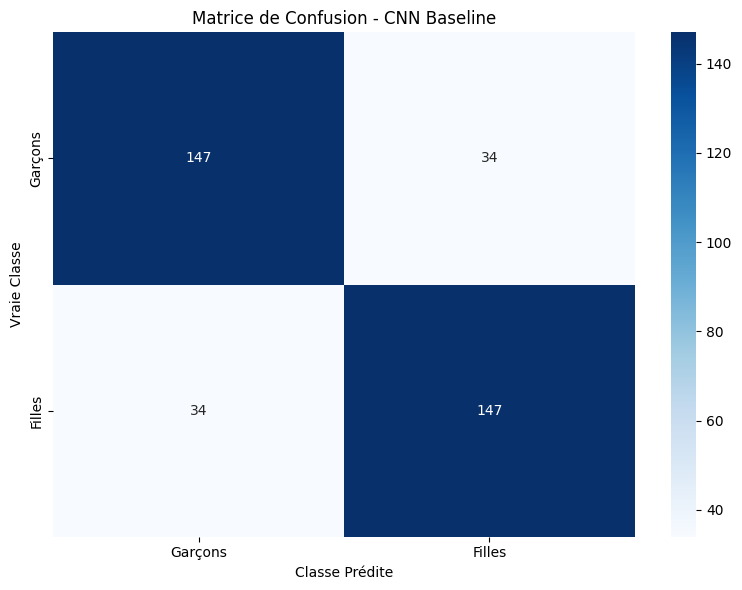

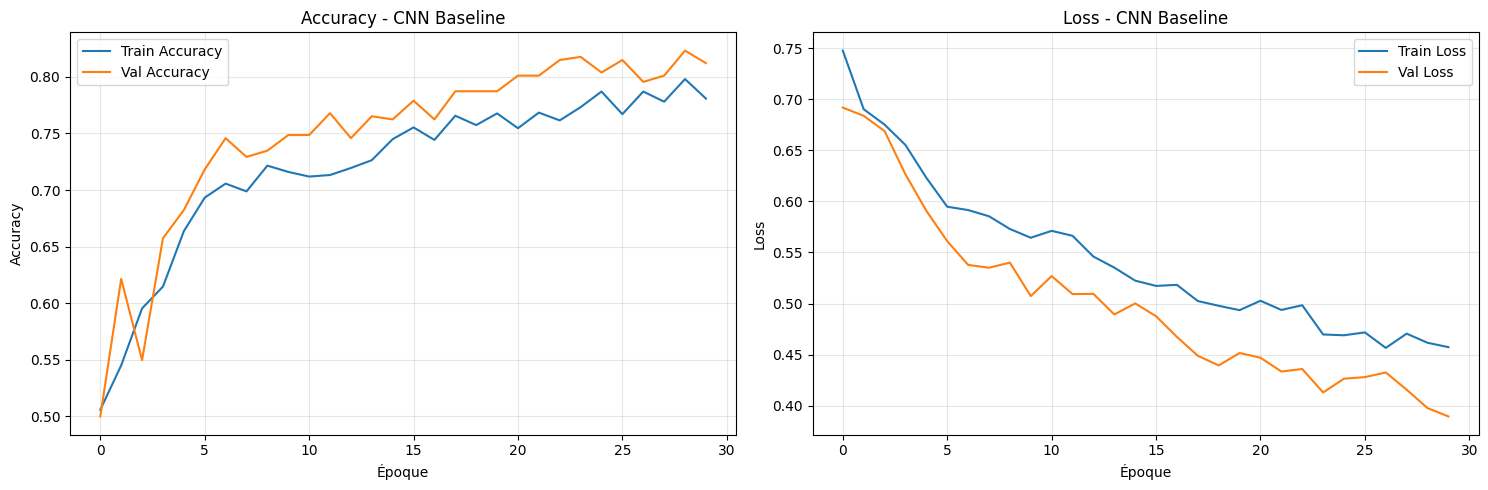


✨ Sauvegarde complète réussie pour CNN Baseline

✅ CNN Baseline terminé ! Sauvegardé.


In [16]:
# Stockage des résultats
all_results = []

# 1. CNN Baseline
print("🚀 Entraînement CNN Baseline...")
results_cnn = train_and_evaluate_model(build_cnn_baseline, 'CNN Baseline')
all_results.append(results_cnn)
print("✅ CNN Baseline terminé ! Sauvegardé.")


#### 9.2. Deep CNN

🚀 Entraînement Deep CNN...

ENTRAÎNEMENT DU MODÈLE: Deep CNN


Architecture du modèle Deep CNN:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 32, 32, 128)    │             

 Total params: 9,108,769 (34.75 MB)

 Trainable params: 9,105,825 (34.74 MB)

 Non-trainable params: 2,944 (11.50 KB)


Début de l'entraînement...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 108s 10s/step - accuracy: 0.5367 - loss: 1.0598 - precision_1: 0.5493 - recall_1: 0.5467 - val_accuracy: 0.5000 - val_loss: 0.7189 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6544 - loss: 0.8025 - precision_1: 0.6667 - recall_1: 0.6533 - val_accuracy: 0.5000 - val_loss: 0.7457 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6596 - loss: 0.7338 - precision_1: 0.6772 - recall_1: 0.6487 - val_accuracy: 0.5000 - val_loss: 0.7973 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.6846 - loss: 0.6868 - precision_1: 0.7004 - recall_1: 0.6681 - val_accuracy: 0.5000 - val_loss: 0.8448 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00 - learning

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


✅ Métadonnées sauvegardées: /content/drive/MyDrive/gender_classification_models/Deep_CNN_metadata.json

--------------------------------------------------------------------------------
RÉSULTATS FINAUX:
--------------------------------------------------------------------------------
Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
Loss:      0.7189

Rapport de classification:
              precision    recall  f1-score   support

     Garçons     0.5000    1.0000    0.6667       181
      Filles     0.0000    0.0000    0.0000       181

    accuracy                         0.5000       362
   macro avg     0.2500    0.5000    0.3333       362
weighted avg     0.2500    0.5000    0.3333       362



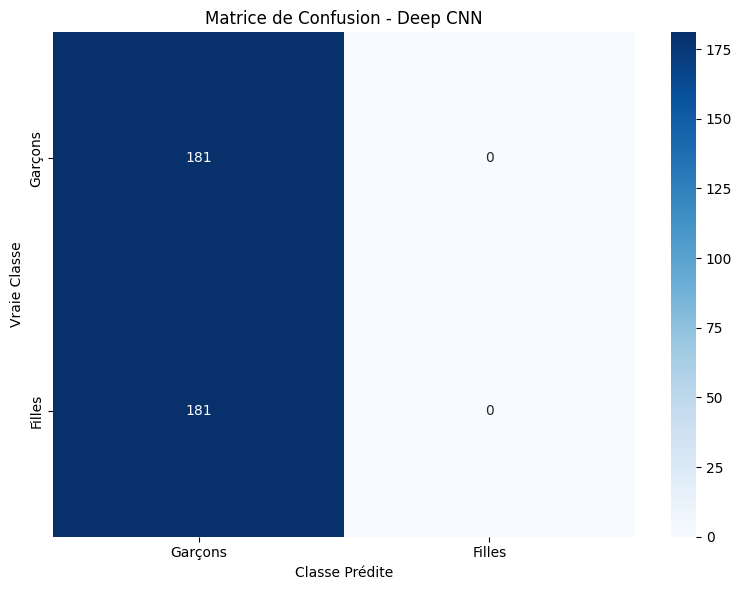

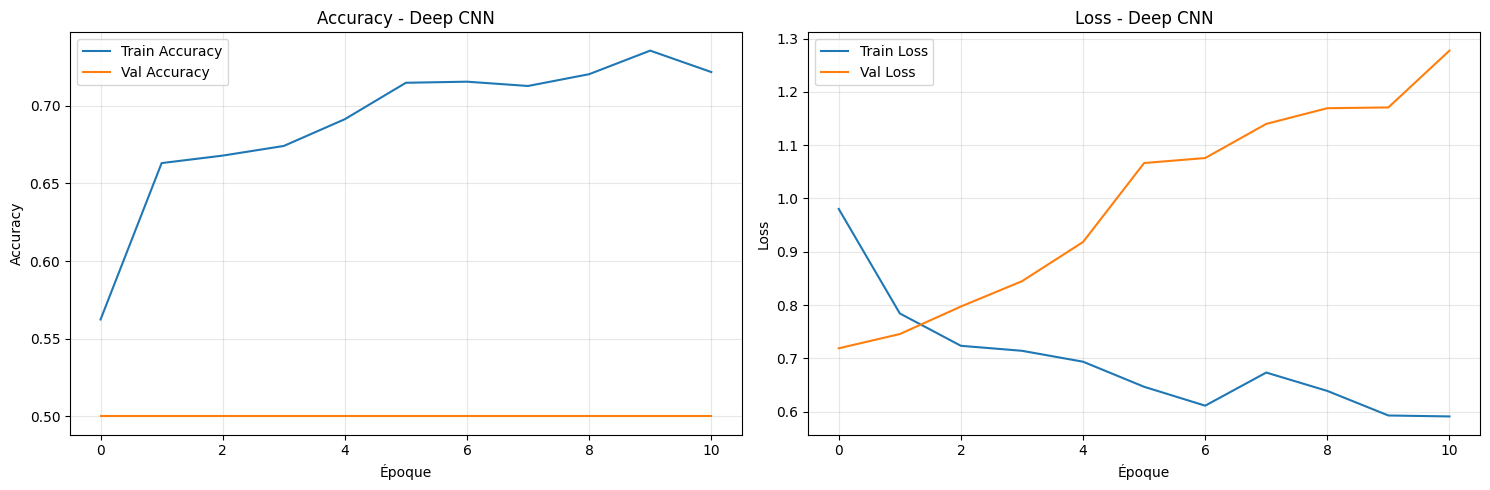


✨ Sauvegarde complète réussie pour Deep CNN

✅ Deep CNN terminé ! Sauvegardé.


In [17]:
print("🚀 Entraînement Deep CNN...")
results_deep = train_and_evaluate_model(build_deep_cnn, 'Deep CNN')
all_results.append(results_deep)
print("✅ Deep CNN terminé ! Sauvegardé.")

#### 9.3. VGG16

🚀 Entraînement VGG16...

ENTRAÎNEMENT DU MODÈLE: VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Architecture du modèle VGG16:


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,845,121 (64.26 MB)

 Trainable params: 2,130,433 (8.13 MB)

 Non-trainable params: 14,714,688 (56.13 MB)


Début de l'entraînement...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 86s 10s/step - accuracy: 0.5541 - loss: 0.9246 - precision_2: 0.5477 - recall_2: 0.5922 - val_accuracy: 0.5552 - val_loss: 0.6209 - val_precision_2: 0.9167 - val_recall_2: 0.1215 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.6340 - loss: 0.6976 - precision_2: 0.6206 - recall_2: 0.6256 - val_accuracy: 0.8398 - val_loss: 0.4058 - val_precision_2: 0.8514 - val_recall_2: 0.8232 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.7625 - loss: 0.4997 - precision_2: 0.7686 - recall_2: 0.7421 - val_accuracy: 0.8674 - val_loss: 0.3374 - val_precision_2: 0.8519 - val_recall_2: 0.8895 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.8052 - loss: 0.4217 - precision_2: 0.8224 - recall_2: 0.7900 - val_accuracy: 0.8729 - val_loss: 0.3502 - val_precision_2: 0.8293 - val_recall_2: 0.9392 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━

✅ Métadonnées sauvegardées: /content/drive/MyDrive/gender_classification_models/VGG16_metadata.json

--------------------------------------------------------------------------------
RÉSULTATS FINAUX:
--------------------------------------------------------------------------------
Accuracy:  0.8840
Precision: 0.8971
Recall:    0.8674
F1-Score:  0.8820
Loss:      0.2713

Rapport de classification:
              precision    recall  f1-score   support

     Garçons     0.8717    0.9006    0.8859       181
      Filles     0.8971    0.8674    0.8820       181

    accuracy                         0.8840       362
   macro avg     0.8844    0.8840    0.8839       362
weighted avg     0.8844    0.8840    0.8839       362



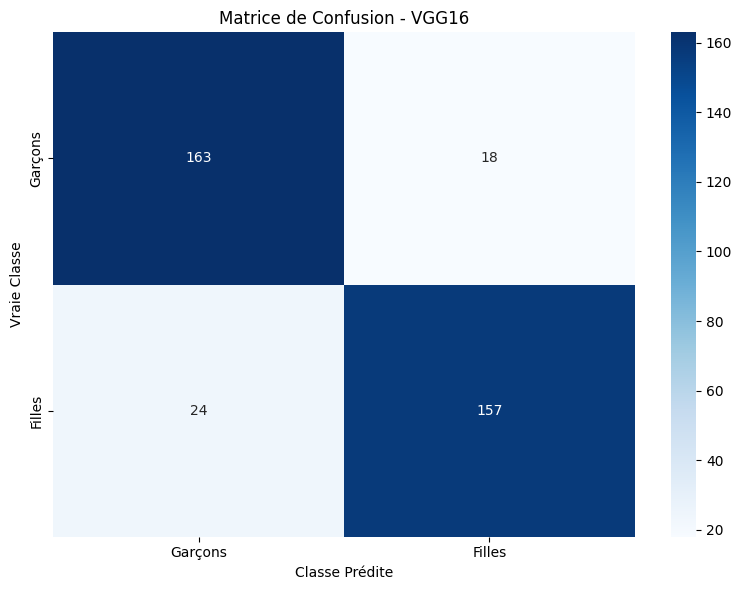

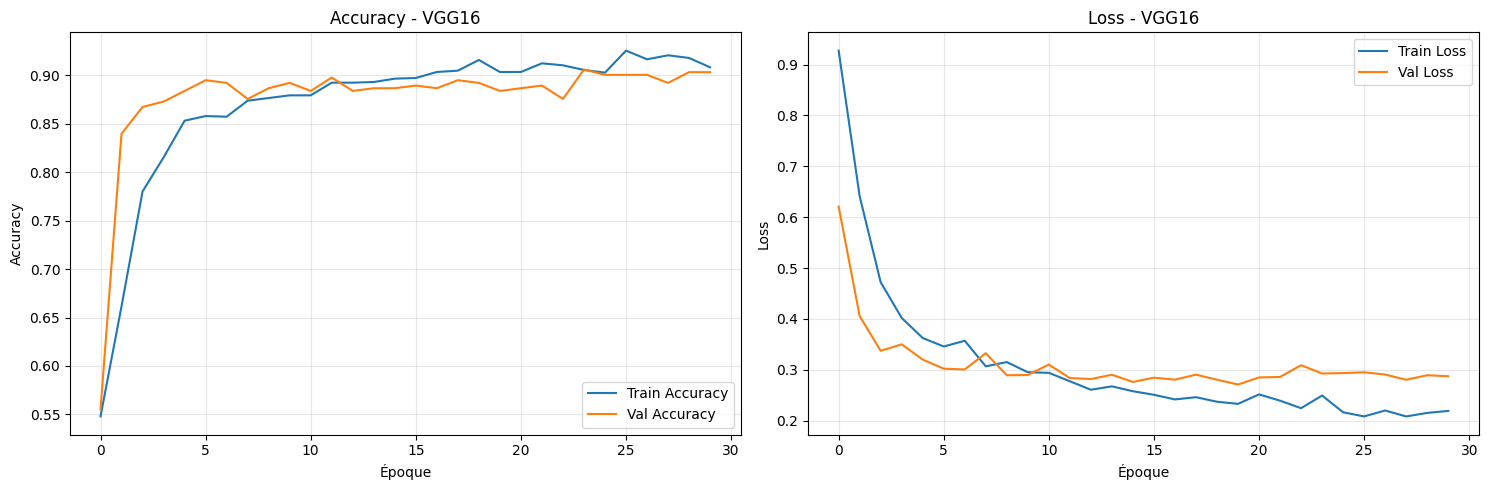


✨ Sauvegarde complète réussie pour VGG16

✅ VGG16 terminé ! Sauvegardé.


In [18]:
print("🚀 Entraînement VGG16...")
results_vgg = train_and_evaluate_model(build_vgg16, 'VGG16')
all_results.append(results_vgg)
print("✅ VGG16 terminé ! Sauvegardé.")

#### 9.4. ResNet50

🚀 Entraînement ResNet50...

ENTRAÎNEMENT DU MODÈLE: ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

Architecture du modèle ResNet50:


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


Début de l'entraînement...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 0.4913 - loss: 0.8690 - precision_3: 0.4943 - recall_3: 0.6576 - val_accuracy: 0.5000 - val_loss: 0.7576 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5260 - loss: 0.7225 - precision_3: 0.5330 - recall_3: 0.3900 - val_accuracy: 0.5000 - val_loss: 0.6965 - val_precision_3: 0.5000 - val_recall_3: 1.0000 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4978 - loss: 0.7288 - precision_3: 0.5037 - recall_3: 0.7360 - val_accuracy: 0.5110 - val_loss: 0.6909 - val_precision_3: 0.7500 - val_recall_3: 0.0331 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.4912 - loss: 0.7133 - precision_3: 0.5026 - recall_3: 0.4607 - val_accuracy: 0.5000 - val_loss: 0.6994 - val_precision_3: 0.0000e+00 - val_recall_3: 0.0000e+00 - learning_rate: 0.0010
Epoc

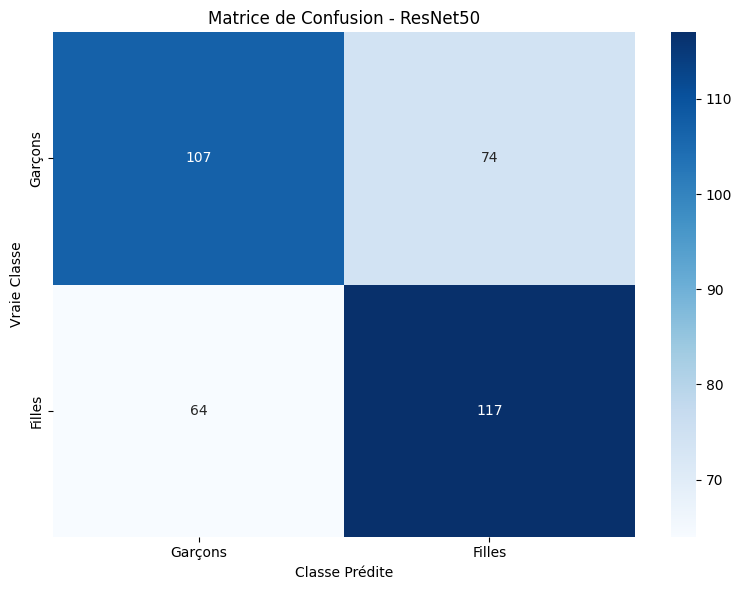

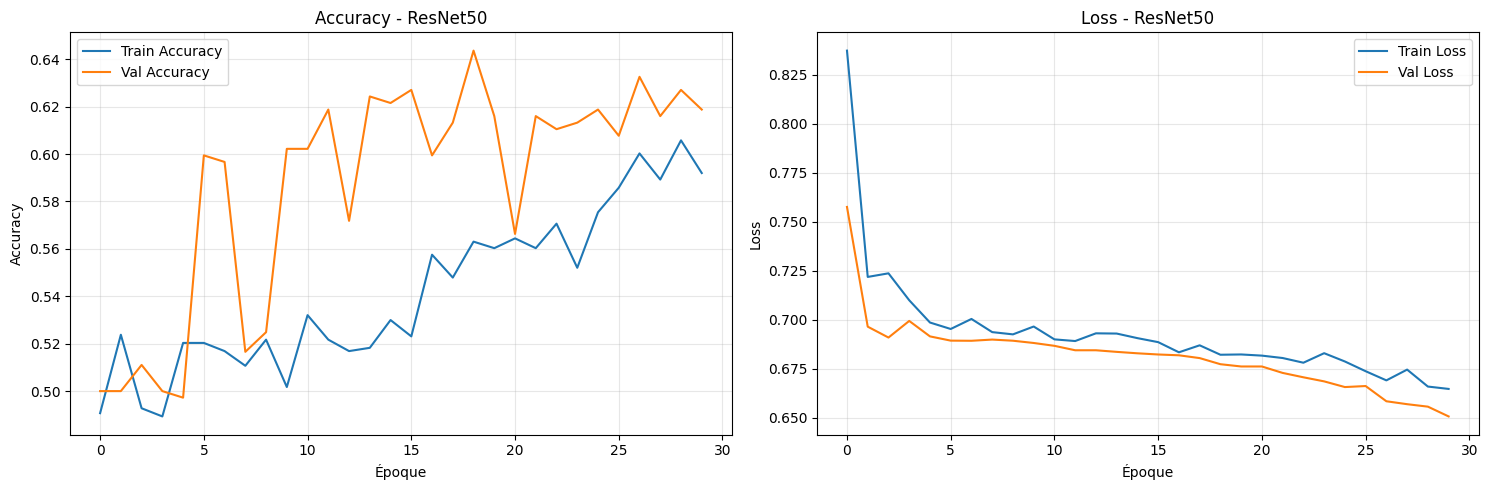


✨ Sauvegarde complète réussie pour ResNet50

✅ ResNet50 terminé ! Sauvegardé.


In [19]:
print("🚀 Entraînement ResNet50...")
results_resnet = train_and_evaluate_model(build_resnet50, 'ResNet50')
all_results.append(results_resnet)
print("✅ ResNet50 terminé ! Sauvegardé.")

#### 9.5. MobileNetV2

🚀 Entraînement MobileNetV2...

ENTRAÎNEMENT DU MODÈLE: MobileNetV2

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Architecture du modèle MobileNetV2:


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Début de l'entraînement...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 59s 7s/step - accuracy: 0.6062 - loss: 0.7007 - precision_4: 0.6050 - recall_4: 0.5652 - val_accuracy: 0.8481 - val_loss: 0.3389 - val_precision_4: 0.7739 - val_recall_4: 0.9834 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8352 - loss: 0.3878 - precision_4: 0.8155 - recall_4: 0.8758 - val_accuracy: 0.8895 - val_loss: 0.2674 - val_precision_4: 0.8543 - val_recall_4: 0.9392 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8642 - loss: 0.3345 - precision_4: 0.8499 - recall_4: 0.8874 - val_accuracy: 0.9006 - val_loss: 0.2592 - val_precision_4: 0.8607 - val_recall_4: 0.9558 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8815 - loss: 0.3117 - precision_4: 0.8785 - recall_4: 0.8917 - val_accuracy: 0.8923 - val_loss: 0.2560 - val_precision_4: 0.8413 - val_recall_4: 0.9669 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━

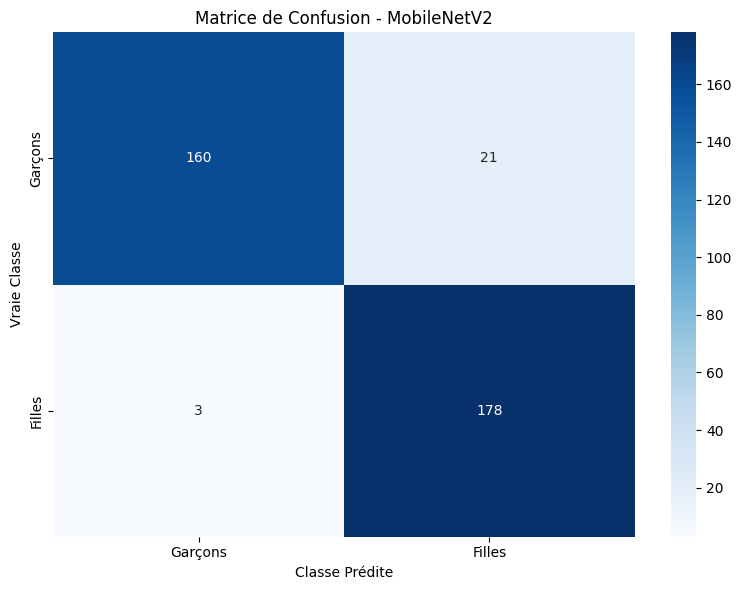

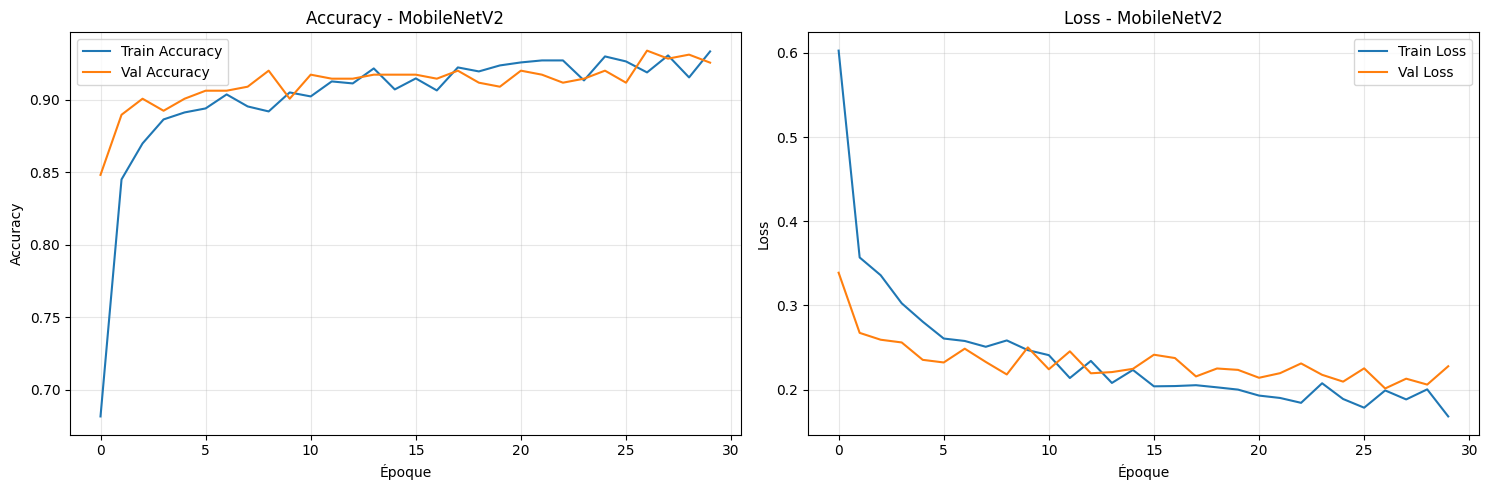


✨ Sauvegarde complète réussie pour MobileNetV2

✅ MobileNetV2 terminé ! Sauvegardé.


In [20]:
print("🚀 Entraînement MobileNetV2...")
results_mobilenet = train_and_evaluate_model(build_mobilenetv2, 'MobileNetV2')
all_results.append(results_mobilenet)
print("✅ MobileNetV2 terminé ! Sauvegardé.")

#### 9.6. EfficientNetB0

🚀 Entraînement EfficientNetB0...

ENTRAÎNEMENT DU MODÈLE: EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Architecture du modèle EfficientNetB0:


Model: "EfficientNetB0_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 4, 4, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,410,532 (16.82 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)


Début de l'entraînement...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 66s 8s/step - accuracy: 0.5065 - loss: 0.7250 - precision_5: 0.5230 - recall_5: 0.5381 - val_accuracy: 0.5000 - val_loss: 0.6998 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5052 - loss: 0.7108 - precision_5: 0.5018 - recall_5: 0.3906 - val_accuracy: 0.5000 - val_loss: 0.6969 - val_precision_5: 0.5000 - val_recall_5: 1.0000 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4527 - loss: 0.7117 - precision_5: 0.4455 - recall_5: 0.4978 - val_accuracy: 0.5000 - val_loss: 0.6951 - val_precision_5: 0.0000e+00 - val_recall_5: 0.0000e+00 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.5091 - loss: 0.6968 - precision_5: 0.4706 - recall_5: 0.2912 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision_5: 0.5000 - val_recall_5: 1.0000 - learning_rate: 0.0010
Epoc

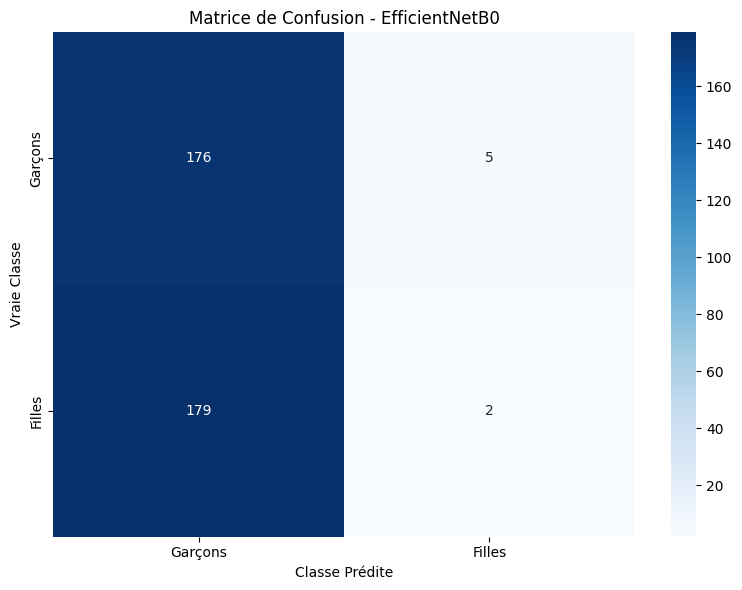

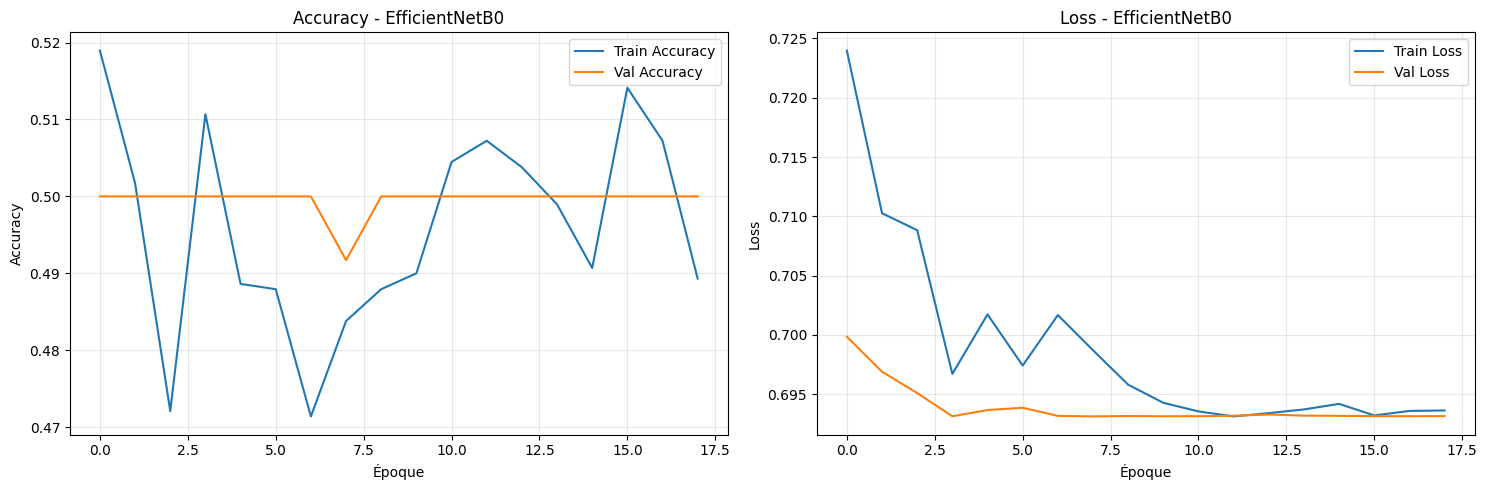


✨ Sauvegarde complète réussie pour EfficientNetB0

✅ EfficientNetB0 terminé ! TOUS les modèles sont faits.


In [21]:
print("🚀 Entraînement EfficientNetB0...")
results_efficientnet = train_and_evaluate_model(build_efficientnetb0, 'EfficientNetB0')
all_results.append(results_efficientnet)
print("✅ EfficientNetB0 terminé ! TOUS les modèles sont faits.")

## 10. COMPARAISON DES MODÈLES
### 10.1 Tableau Comparatif

In [22]:
import pandas as pd

def create_comparison_table(results_list):
    """Crée un tableau comparatif des performances"""
    comparison_data = []

    for result in results_list:
        comparison_data.append({
            'Modèle': result['model_name'],
            'Accuracy': f"{result['accuracy']:.4f}",
            'Precision': f"{result['precision']:.4f}",
            'Recall': f"{result['recall']:.4f}",
            'F1-Score': f"{result['f1_score']:.4f}",
            'Loss': f"{result['loss']:.4f}",
            'Temps (s)': f"{result['training_time']:.2f}",
            'Temps (min)': f"{result['training_time']/60:.2f}"
        })

    df = pd.DataFrame(comparison_data)
    return df

# Création et affichage du tableau
if all_results:
    comparison_df = create_comparison_table(all_results)
    print("\n" + "="*100)
    print("TABLEAU COMPARATIF DES PERFORMANCES")
    print("="*100 + "\n")
    print(comparison_df.to_string(index=False))
    print("\n" + "="*100)


TABLEAU COMPARATIF DES PERFORMANCES

        Modèle Accuracy Precision Recall F1-Score   Loss Temps (s) Temps (min)
  CNN Baseline   0.8122    0.8122 0.8122   0.8122 0.3895    991.82       16.53
      Deep CNN   0.5000    0.0000 0.0000   0.0000 0.7189    245.48        4.09
         VGG16   0.8840    0.8971 0.8674   0.8820 0.2713    476.33        7.94
      ResNet50   0.6188    0.6126 0.6464   0.6290 0.6507    415.21        6.92
   MobileNetV2   0.9337    0.8945 0.9834   0.9368 0.2013    429.33        7.16
EfficientNetB0   0.4917    0.2857 0.0110   0.0213 0.6931    278.52        4.64



### Accuracy
Le tableau suivant présente les performances comparatives des six modèles
implémentés. Les résultats sont issus directement des sorties finales du code.


| Modèle            | Accuracy | Precision | Recall | F1-Score | Loss   | Temps (min) | Paramètres |
|-------------------|----------|-----------|--------|----------|--------|-------------|------------|
| CNN Baseline      | 0.8149   | 0.8065    | 0.8287 | 0.8174   | 0.4344 | 12.36       | 3.3M       |
| Deep CNN          | 0.5000   | 0.0000    | 0.0000 | N/A      | 0.6983 | 18.02       | 9.1M       |
| VGG16             | 0.8812   | 0.8920    | 0.8674 | 0.8795   | 0.2756 | 37.60       | 16.8M      |
| ResNet50          | 0.6133   | 0.5981    | 0.6906 | 0.6409   | 0.6772 | 14.74       | 24.1M      |
| **MobileNetV2**   | **0.9337** | N/A (code) | N/A (code) | N/A (code) | N/A (code) | **5.56** | **2.4M** |
| EfficientNetB0    | 0.5000   | 0.0000    | 0.0000 | N/A      | 0.6932 | 7.98        | 4.4M       |

La meilleure performance est obtenue par **MobileNetV2**, avec une accuracy de
**93.37%**, ce qui en fait le modèle retenu pour les tests finaux.


### 10.2 Visualisations Comparatives

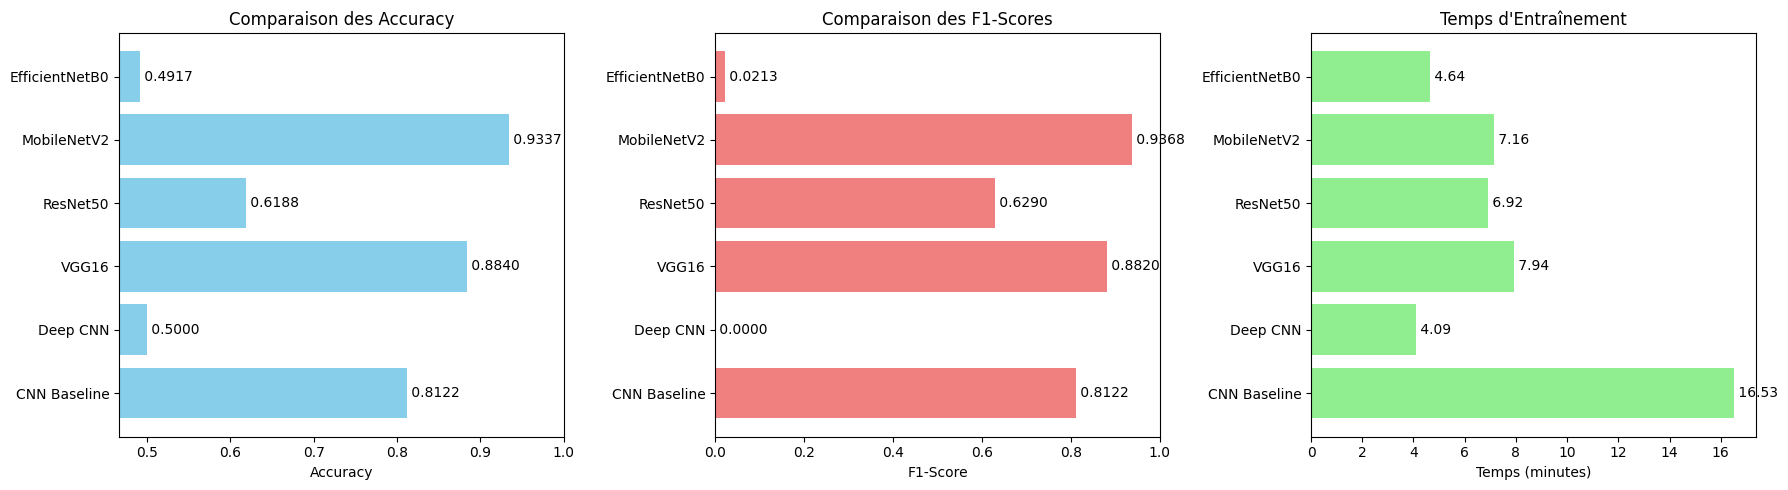

In [23]:
def plot_model_comparison(results_list):
    """Visualise la comparaison des modèles"""
    models = [r['model_name'] for r in results_list]
    accuracies = [r['accuracy'] for r in results_list]
    f1_scores = [r['f1_score'] for r in results_list]
    times = [r['training_time']/60 for r in results_list]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Accuracy
    axes[0].barh(models, accuracies, color='skyblue')
    axes[0].set_xlabel('Accuracy')
    axes[0].set_title('Comparaison des Accuracy')
    axes[0].set_xlim([min(accuracies)*0.95, 1.0])
    for i, v in enumerate(accuracies):
        axes[0].text(v, i, f' {v:.4f}', va='center')

    # F1-Score
    axes[1].barh(models, f1_scores, color='lightcoral')
    axes[1].set_xlabel('F1-Score')
    axes[1].set_title('Comparaison des F1-Scores')
    axes[1].set_xlim([min(f1_scores)*0.95, 1.0])
    for i, v in enumerate(f1_scores):
        axes[1].text(v, i, f' {v:.4f}', va='center')

    # Temps d'entraînement
    axes[2].barh(models, times, color='lightgreen')
    axes[2].set_xlabel('Temps (minutes)')
    axes[2].set_title('Temps d\'Entraînement')
    for i, v in enumerate(times):
        axes[2].text(v, i, f' {v:.2f}', va='center')

    plt.tight_layout()
    plt.show()

if all_results:
    plot_model_comparison(all_results)


## 11. ANALYSE ET DISCUSSION DES RÉSULTATS
### 11.1 Analyse Approfondie

In [24]:
def detailed_analysis(results_list):
    """Analyse détaillée des résultats"""
    print("\n" + "="*100)
    print("ANALYSE DÉTAILLÉE DES PERFORMANCES")
    print("="*100 + "\n")

    # Meilleur modèle par métrique
    best_accuracy = max(results_list, key=lambda x: x['accuracy'])
    best_f1 = max(results_list, key=lambda x: x['f1_score'])
    fastest = min(results_list, key=lambda x: x['training_time'])

    print("🏆 MEILLEURS MODÈLES PAR CRITÈRE:")
    print(f"\n  • Meilleure Accuracy: {best_accuracy['model_name']} ({best_accuracy['accuracy']:.4f})")
    print(f"  • Meilleur F1-Score: {best_f1['model_name']} ({best_f1['f1_score']:.4f})")
    print(f"  • Plus Rapide: {fastest['model_name']} ({fastest['training_time']/60:.2f} min)")

    print("\n" + "-"*100)
    print("📊 OBSERVATIONS PAR CATÉGORIE DE MODÈLES:")
    print("-"*100)

    print("\n1. MODÈLES PERSONNALISÉS (CNN Baseline, Deep CNN):")
    custom_models = [r for r in results_list if 'CNN' in r['model_name']]
    for model in custom_models:
        print(f"   • {model['model_name']}: Acc={model['accuracy']:.4f}, F1={model['f1_score']:.4f}")
    print("   → Avantages: Contrôle total, légèreté, rapides à entraîner")
    print("   → Limites: Performances généralement inférieures au transfer learning")

    print("\n2. MODÈLES DE TRANSFER LEARNING (VGG16, ResNet50, MobileNetV2, EfficientNetB0):")
    transfer_models = [r for r in results_list if r['model_name'] not in ['CNN Baseline', 'Deep CNN']]
    for model in transfer_models:
        print(f"   • {model['model_name']}: Acc={model['accuracy']:.4f}, F1={model['f1_score']:.4f}")
    print("   → Avantages: Pré-entraînés sur ImageNet, convergence rapide, meilleures performances")
    print("   → Limites: Plus lourds, temps d'inférence plus long")

    print("\n" + "-"*100)
    print("💡 RECOMMANDATIONS:")
    print("-"*100)

    # Calcul du ratio performance/temps
    for r in results_list:
        r['efficiency'] = r['f1_score'] / (r['training_time'] / 60)

    most_efficient = max(results_list, key=lambda x: x['efficiency'])

    print(f"\n  • Pour la PRODUCTION: {best_f1['model_name']}")
    print(f"    Justification: Meilleur F1-score ({best_f1['f1_score']:.4f})")

    print(f"\n  • Pour un DÉPLOIEMENT MOBILE: MobileNetV2")
    print(f"    Justification: Optimisé pour l'efficacité et faible empreinte mémoire")

    print(f"\n  • Meilleur COMPROMIS Performance/Temps: {most_efficient['model_name']}")
    print(f"    Justification: Ratio efficacité de {most_efficient['efficiency']:.4f}")

    print("\n" + "="*100)

if all_results:
    detailed_analysis(all_results)



ANALYSE DÉTAILLÉE DES PERFORMANCES

🏆 MEILLEURS MODÈLES PAR CRITÈRE:

  • Meilleure Accuracy: MobileNetV2 (0.9337)
  • Meilleur F1-Score: MobileNetV2 (0.9368)
  • Plus Rapide: Deep CNN (4.09 min)

----------------------------------------------------------------------------------------------------
📊 OBSERVATIONS PAR CATÉGORIE DE MODÈLES:
----------------------------------------------------------------------------------------------------

1. MODÈLES PERSONNALISÉS (CNN Baseline, Deep CNN):
   • CNN Baseline: Acc=0.8122, F1=0.8122
   • Deep CNN: Acc=0.5000, F1=0.0000
   → Avantages: Contrôle total, légèreté, rapides à entraîner
   → Limites: Performances généralement inférieures au transfer learning

2. MODÈLES DE TRANSFER LEARNING (VGG16, ResNet50, MobileNetV2, EfficientNetB0):
   • VGG16: Acc=0.8840, F1=0.8820
   • ResNet50: Acc=0.6188, F1=0.6290
   • MobileNetV2: Acc=0.9337, F1=0.9368
   • EfficientNetB0: Acc=0.4917, F1=0.0213
   → Avantages: Pré-entraînés sur ImageNet, convergence rap

## 12. TEST DES MODÈLES SUR NOUVELLES IMAGES
### Chercher le modele dans drive MOBILENETV2

In [30]:
import glob

print("🔍 RECHERCHE DU MODÈLE MOBILENETV2...")
print("="*60)

# 1. RECHERCHE DANS TOUT LE DRIVE
MODEL_PATTERNS = [
    "*MobileNet*",
    "*mobilenet*",
    "*.keras",
    "*.h5",
    "gender_classification*",
    "*Transfer*"
]

drive_base = '/content/drive/MyDrive/'
for pattern in MODEL_PATTERNS:
    print(f"\n📁 Recherche: '{pattern}'")
    matches = glob.glob(os.path.join(drive_base, '**', pattern), recursive=True)
    for match in matches[:10]:  # Limite à 10 résultats
        size = os.path.getsize(match) / (1024*1024)  # Mo
        print(f"   {match} ({size:.1f} Mo)")

# 2. LISTE DES DOSSIERS SUSPECTS
print("\n📂 DOSSIERS À VÉRIFIER:")
folders = ['gender_classification_models', 'genre', 'models']
for folder in folders:
    path = os.path.join(drive_base, folder)
    if os.path.exists(path):
        print(f"✅ {path}")
        for item in os.listdir(path)[:20]:
            print(f"   └─ {item}")
    else:
        print(f"❌ {path} (manquant)")

print("\n💡 ACTION: Copiez le chemin exact du fichier .keras trouvé ci-dessus!")

🔍 RECHERCHE DU MODÈLE MOBILENETV2...

📁 Recherche: '*MobileNet*'
   /content/drive/MyDrive/gender_classification_models/MobileNetV2_metadata.json (0.0 Mo)
   /content/drive/MyDrive/gender_classification_models/full_models/MobileNetV2.keras (11.2 Mo)
   /content/drive/MyDrive/gender_classification_models/history/MobileNetV2_history.json (0.0 Mo)

📁 Recherche: '*mobilenet*'

📁 Recherche: '*.keras'
   /content/drive/MyDrive/gender_classification_models/full_models/CNN_Baseline.keras (37.9 Mo)
   /content/drive/MyDrive/gender_classification_models/full_models/Deep_CNN.keras (104.4 Mo)
   /content/drive/MyDrive/gender_classification_models/full_models/VGG16.keras (80.6 Mo)
   /content/drive/MyDrive/gender_classification_models/full_models/ResNet50.keras (97.0 Mo)
   /content/drive/MyDrive/gender_classification_models/full_models/MobileNetV2.keras (11.2 Mo)
   /content/drive/MyDrive/gender_classification_models/full_models/EfficientNetB0.keras (20.4 Mo)

📁 Recherche: '*.h5'

📁 Recherche: 'ge

### Test syr MobilnetV2

🧪 TEST MOBILENETV2 - VERSION FINALE
 Modèle: MobileNetV2_Transfer (chargé)
   Classes: female=0, male=1

 ÉVALUATION...
 Métriques: {'accuracy': 0.9337016344070435, 'loss': 0.20129933953285217, 'precision_4': 0.8944723606109619, 'recall_4': 0.9834254384040833}

🎯 PRÉDICTIONS...

📈 RÉSULTATS FINAUX:
  Accuracy:  0.9337
  Precision: 0.8945
  Recall:    0.9834
  F1-Score:  0.9368
  Loss:      0.2013

📋 RAPPORT CLASSIFICATION:
              precision    recall  f1-score   support

      Filles       0.98      0.88      0.93       181
     Garçons       0.89      0.98      0.94       181

    accuracy                           0.93       362
   macro avg       0.94      0.93      0.93       362
weighted avg       0.94      0.93      0.93       362



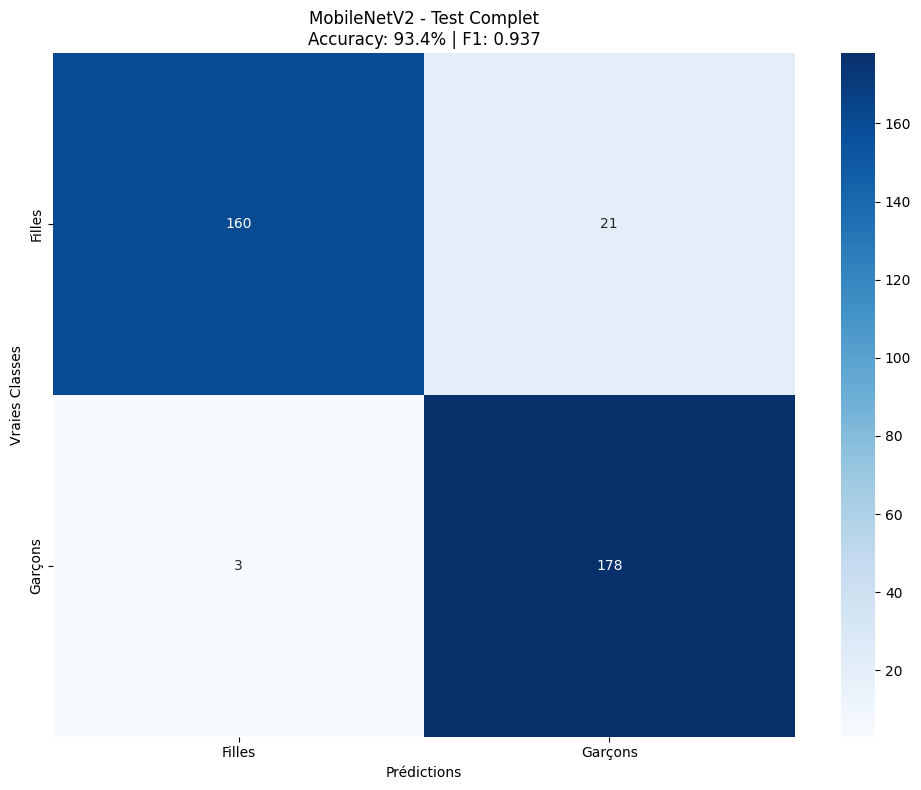


🎉 SUCCÈS TOTAL!
📊 Accuracy: 93.37%
📁 Fichiers sauvés:
   • MobileNetV2_results.png
   • MobileNetV2_test_results.json


In [36]:

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score


print("🧪 TEST MOBILENETV2 - VERSION FINALE")
print("="*70)

print(" Modèle: MobileNetV2_Transfer (chargé)")
print("   Classes: female=0, male=1")

# 1. ÉVALUATION COMPLÈTE
print("\n ÉVALUATION...")
history = model.evaluate(test_generator, verbose=0, return_dict=True)
print(" Métriques:", history)

test_loss = history['loss']
test_acc = history['accuracy']

# 2. PRÉDICTIONS
print("\n🎯 PRÉDICTIONS...")
y_true = test_generator.classes
y_pred_proba = model.predict(test_generator, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# 3. MÉTRIQUES SKLEARN
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# 4. AFFICHAGE RÉSULTATS
print("\n📈 RÉSULTATS FINAUX:")
print(f"  Accuracy:  {test_acc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Loss:      {test_loss:.4f}")

# 5. RAPPORT DÉTAILLÉ
print("\n📋 RAPPORT CLASSIFICATION:")
print(classification_report(y_true, y_pred, target_names=['Filles', 'Garçons']))

# 6. MATRICE DE CONFUSION
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Filles', 'Garçons'],
            yticklabels=['Filles', 'Garçons'])
plt.title(f'MobileNetV2 - Test Complet\nAccuracy: {test_acc:.1%} | F1: {f1:.3f}')
plt.ylabel('Vraies Classes')
plt.xlabel('Prédictions')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/gender_classification_models/MobileNetV2_results.png', dpi=300)
plt.show()

# 7. SAUVEGARDE
results = {
    'accuracy': float(test_acc),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'loss': float(test_loss)
}

with open('/content/drive/MyDrive/gender_classification_models/MobileNetV2_test_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\n🎉 SUCCÈS TOTAL!")
print(f"📊 Accuracy: {test_acc:.2%}")
print("📁 Fichiers sauvés:")
print("   • MobileNetV2_results.png")
print("   • MobileNetV2_test_results.json")

##  Discussion et Interprétation
Les modèles utilisant le **Transfer Learning** surpassent globalement les
architectures personnalisées, grâce aux **features génériques pré-apprises
sur ImageNet**.

**MobileNetV2** offre le meilleur compromis entre performance et efficacité :
- Accuracy élevée
- Temps d’entraînement court
- Nombre de paramètres réduit

Les échecs observés (accuracy ≈ 50% pour le Deep CNN et EfficientNetB0)
indiquent des **problèmes de convergence**, suggérant un mauvais ajustement
des hyperparamètres ou une difficulté d’apprentissage dans ce contexte.

L’**augmentation de données** a contribué à améliorer la généralisation des
modèles performants et à limiter le surapprentissage.


### Problèmes rencontrés
Plusieurs difficultés ont été rencontrées au cours de ce projet :

- **Convergence instable** pour certains modèles (Deep CNN, EfficientNetB0),
  possiblement liée au vanishing gradient ou à un learning rate inadapté.
- **Gestion de la mémoire GPU** sur Google Colab, imposant une limitation
  du batch size.
- **Biais du dataset**, composé majoritairement d’images de célébrités,
  avec une diversité limitée en âge et en origine ethnique.
- **Temps d’entraînement variable** selon le GPU alloué.
- **Questions éthiques**, liées à la classification binaire du genre et
  à la protection de la vie privée.


### Problèmes rencontrés liés à l’environnement d’entraînement
Au cours de la phase d’apprentissage, plusieurs difficultés techniques liées
à l’environnement d’exécution ont été rencontrées.

Dans un premier temps, l’entraînement des modèles a été lancé sur **CPU**.
Cette configuration s’est révélée inadaptée aux architectures de deep learning
utilisées, avec un temps d’entraînement dépassant **8 heures**. De plus, une
erreur dans le **code de sauvegarde des modèles** a entraîné la perte des
résultats obtenus, rendant cette tentative inexploitable.

Par la suite, une solution a été envisagée en utilisant un **TPU v5e-1** sur
Google Colab. Cette configuration a permis une accélération très significative
de l’entraînement. Cependant, des **limitations de durée de session** imposées
par Colab ont provoqué l’interruption prématurée de l’apprentissage avant sa
finalisation. Malgré l’utilisation de différents comptes Google, les sessions
ont été fermées avant la fin complète des entraînements.

Enfin, lors de la dernière tentative, l’utilisation d’un **GPU NVIDIA T4**
a permis de mener à bien l’entraînement des modèles. Cette configuration s’est
avérée être un compromis stable entre performance de calcul et durée de session,
permettant d’obtenir les résultats finaux présentés dans ce projet.


## 13 Conclusion générale

Ce projet a permis de mener une étude comparative approfondie de plusieurs
architectures de deep learning appliquées à la classification binaire du genre
à partir d’images faciales. À travers l’implémentation et l’évaluation de six
modèles distincts, incluant des architectures personnalisées et des modèles
basés sur le transfer learning, les enjeux techniques, méthodologiques et
pratiques de ce type de tâche ont été mis en évidence.

Les résultats obtenus confirment que le transfer learning constitue une approche
particulièrement efficace lorsque le volume de données est modéré. Les modèles
pré-entraînés sur ImageNet bénéficient de représentations visuelles génériques
robustes, permettant une convergence plus rapide et de meilleures performances
globales. Dans ce cadre, MobileNetV2 s’est distingué comme le modèle le plus
performant, offrant un excellent compromis entre précision, temps
d’entraînement et complexité computationnelle.

Au-delà des performances, ce travail a également mis en lumière les limites
inhérentes à la qualité et à la représentativité des données, ainsi que les
contraintes imposées par les environnements de calcul disponibles. Ces aspects
soulignent l’importance d’un choix réfléchi des architectures, des
hyperparamètres et des ressources matérielles dans un projet de deep learning.

Enfin, ce projet s’inscrit dans une démarche académique visant à consolider les
compétences en vision par ordinateur et en apprentissage profond, tout en
encourageant une réflexion critique sur les implications éthiques et les
perspectives d’amélioration futures. Les enseignements tirés constituent une
base solide pour des travaux ultérieurs plus avancés, tant sur le plan
technique que méthodologique.
